In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
import scipy.integrate as integ
from functions import *

mpl.rc('xtick', direction='in', top=True)
mpl.rc('ytick', direction='in', right=True)
mpl.rc('xtick.minor', visible=True)
mpl.rc('ytick.minor', visible=True)


## Goal:

Have H increase linearly w.r.t time and then decrease linearly w.r.t time, graph Q vs T for this scenario. It is unlikely we will see the expected spike as H decreases to the critical point. <br>
 
Now let $q$ be defined by the differential $\tau \frac{dq}{dt} = -q + k|\alpha \Delta T - \beta \Delta S|$ integrate this to get q as H increases given the known relationship $\frac{d \Delta S}{dt} = 2H - 2|q| \Delta S$ <br>
Need to figure out what $\tau$ should be here, Cyrus guesses in the range of 1-2 centuries

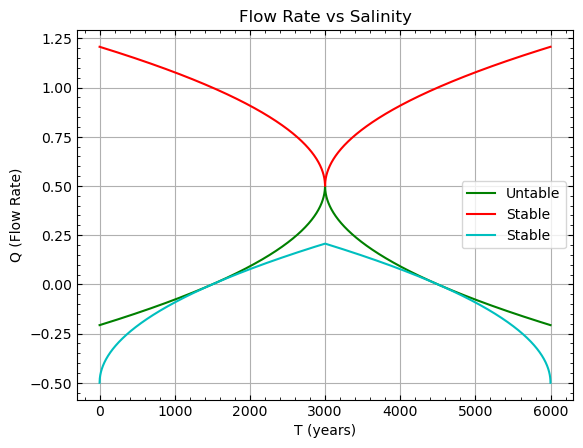

In [34]:
beta = 2.5
alpha = 1
delT = 0.5
k = 2
Args = [beta,alpha,delT,k] # Define arguments

H_inc = getH(Args,3000) # List of 3000 equally spaced values of H between 0 and the maximum such that the eq. sol of dDS/dt is real
H_dec = np.flip(H_inc) # Get the decreasing version of this list (max to 0 rather than 0 to max)
H = np.append(H_inc,H_dec) # Append together to get an evenly space list that goes from 0 to the max H in 3000 steps and then back to 0 in another 3000 steps

time = np.arange(0,6000,1) # time array (0,1,2,...,5999) assuming these to be years
qs = q_H(H, Args)
plt.plot(time, qs[0], color='g',label='Untable')
plt.plot(time, qs[1], color='r',label='Stable')
plt.plot(time, qs[2], color='c',label='Stable')
plt.title('Flow Rate vs Salinity')
plt.xlabel('T (years)')
plt.ylabel('Q (Flow Rate)')
plt.grid()
plt.legend()


This shows all the equilibrium states at a given time, need to adjust to be the expected state rather than all (ie we want to start in the high flow stable, reach a point where we dive into unstable which lands us in the low flow stable) This can be done by going from the red zone to the green where they meet and then the cyan the second time green and cyan meet

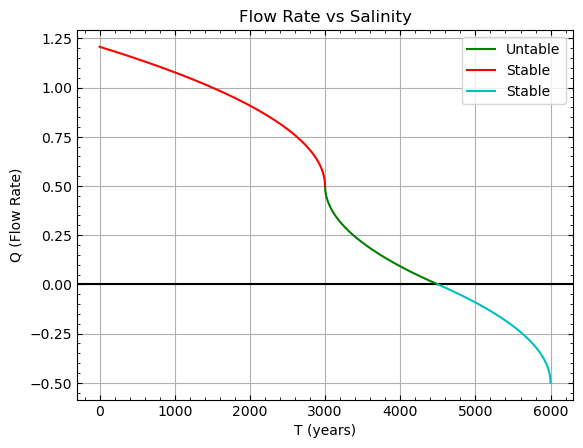

In [35]:
# Now it is obvious for the red zone we want exactly half the curve so:
qRed = qs[1][:3000]
tRed = time[:3000]

# For the green section we start at 3000 and stop when H is 0 during its decreasing portion, this should be at 4500
intersect = 4500
qGreen = qs[0][3000:intersect]
tGreen = time[3000:intersect]

# Lastly for cyan we just go from 4500 to the end
qCyan = qs[2][intersect:]
tCyan = time[intersect:]

plt.axhline(0,color='k')
plt.plot(tGreen, qGreen, color='g',label='Untable')
plt.plot(tRed, qRed, color='r',label='Stable')
plt.plot(tCyan, qCyan, color='c',label='Stable')
plt.title('Flow Rate vs Salinity')
plt.xlabel('T (years)')
plt.ylabel('Q (Flow Rate)')
plt.grid()
plt.legend()


## Redefining $q$ as $q(t)$

This means resolving the system but now instead of just $\Delta S$ being a function of time, $q$ is now also a function of time

In [ ]:
def dqdt1_inc(t, q, args):
    '''
    Equation defining the differential form of q to be solved with the scipy.integrate.solve_ivp function for the first stable equilibirum point

    Parameters:
    t: time
    q: Variable being solved over
    args: array of floats [beta, alpha, Delta T, k, Tau, Hmax, t_length]
    '''

    dH = args[5] / (args[6]/2)
    H = t*dH
    return (-q + args[3]*(args[1]*args[2] - args[0]*(args[1]*args[2] * (1/2 - np.sqrt(1/4 - H*args[0]/(args[3]*(args[1]**2)*(args[2]**2)))) / args[0]))) /args[4]

def dqdt1_dec(t, q, args):
    '''
    Equation defining the differential form of q to be solved with the scipy.integrate.solve_ivp function for the first stable equilibirum point

    Parameters:
    t: time
    q: Variable being solved over
    args: array of floats [beta, alpha, Delta T, k, Tau, Hmax, t_length]
    '''
    dH = args[5] / (args[6]/2)
    H = t*dH
    return (-q + args[3]*(args[1]*args[2] - args[0]*(args[1]*args[2] * (1/2 - np.sqrt(1/4 - H*args[0]/(args[3]*(args[1]**2)*(args[2]**2)))) / args[0]))) /args[4]


In [ ]:
def dqdt2_inc(t, q, args):
    '''
    Equation defining the differential form of q to be solved with the scipy.integrate.solve_ivp function for the second stable equilibrium point

    Parameters:
    t: time
    q: Variable being solved over
    args: array of floats [beta, alpha, Delta T, k, Tau, Hmax, t_length]
    '''
    dH = args[5] / (args[6]/2)
    H = t*dH
    return (-q + args[3]*(args[1]*args[2] - args[0]*(args[1]*args[2] * (1/2 + np.sqrt(1/4 + H*args[0]/(args[3]*(args[1]**2)*(args[2]**2)))) / args[0]))) / args[4]

def dqdt2_dec(t, q, args):
    '''
    Equation defining the differential form of q to be solved with the scipy.integrate.solve_ivp function for the second stable equilibrium point

    Parameters:
    t: time
    q: Variable being solved over
    args: array of floats [beta, alpha, Delta T, k, Tau, Hmax, t_length]
    '''
    dH = args[5] / (args[6]/2)
    H = t*dH
    return (-q + args[3]*(args[1]*args[2] - args[0]*(args[1]*args[2] * (1/2 + np.sqrt(1/4 + H*args[0]/(args[3]*(args[1]**2)*(args[2]**2)))) / args[0]))) / args[4]

In [47]:
q0inc_1 = Args[3]*(Args[1]*Args[2] - Args[0]*(Args[1]*Args[2] * (1/2 - np.sqrt(1/4 - H[0]*Args[0]/(Args[3]*(Args[1]**2)*(Args[2]**2)))) / Args[0])) # Define the initial value (q at H[0]))
q0dec_1 = Args[3]*(Args[1]*Args[2] - Args[0]*(Args[1]*Args[2] * (1/2 - np.sqrt(1/4 - H[3000]*Args[0]/(Args[3]*(Args[1]**2)*(Args[2]**2)))) / Args[0])) # Define the initial value (q at H[0]))
q0inc_2 = Args[3]*(Args[1]*Args[2] - Args[0]*(Args[1]*Args[2] * (1/2 + np.sqrt(1/4 + H[0]*Args[0]/(Args[3]*(Args[1]**2)*(Args[2]**2)))) / Args[0])) # Define the initial value (q at H[0]))
q0dec_2 = Args[3]*(Args[1]*Args[2] - Args[0]*(Args[1]*Args[2] * (1/2 + np.sqrt(1/4 + H[3000]*Args[0]/(Args[3]*(Args[1]**2)*(Args[2]**2)))) / Args[0])) # Define the initial value (q at H[0]))

Tau = 200 # intial guess at time constant (2 centuries)
Hmax = H[3000]
t_length = len(time)
Args.append(Tau)
Args.append(Hmax)
Args.append(t_length)

sol1_inc = integ.solve_ivp(dqdt1_inc, [0,3000], np.array([q0inc_1]), atol=1e-12, rtol=1e-12, args=([Args]), t_eval=(time[:3000]));
sol1_dec = integ.solve_ivp(dqdt1_dec, [0,3000], np.array([q0dec_1]), atol=1e-12, rtol=1e-12, args=([Args]), t_eval=(time[:3000]));

C:\Users\Nathan\AppData\Local\Temp\ipykernel_59656\432479511.py:13: RuntimeWarning: invalid value encountered in sqrt
  return (-q + args[3]*(args[1]*args[2] - args[0]*(args[1]*args[2] * (1/2 - np.sqrt(1/4 - H*args[0]/(args[3]*(args[1]**2)*(args[2]**2)))) / args[0]))) /args[4]
C:\Users\Nathan\AppData\Local\Temp\ipykernel_59656\432479511.py:26: RuntimeWarning: invalid value encountered in sqrt
  return (-q + args[3]*(args[1]*args[2] - args[0]*(args[1]*args[2] * (1/2 - np.sqrt(1/4 - H*args[0]/(args[3]*(args[1]**2)*(args[2]**2)))) / args[0]))) /args[4]
